# How to chunk text into paragraphs — Part 3: doing it in real time, on a CPU

Welcome back! In the first article of this series we split text into paragraphs by building a big sentence-similarity matrix and reading off its valleys. It worked nicely =).

But two things were quietly bugging me. First, just to embed the sentences we had to load a 420 MB model. And second — the bigger one — we needed the **whole** text in front of us before we could even start, because the whole trick lives in that n×n matrix. So if a podcast transcript is coming in live, sentence by sentence, the old approach just sits there and waits for the very last sentence to arrive.

In this article I want to fix both. We are going to make our chunker:

- use **static embeddings** — microseconds per sentence, no GPU, a tiny ~30 MB model;
- work in a **single pass**, deciding the paragraph breaks *on the fly*, as each sentence arrives.

Same idea as before, just real-time and on a laptop. Let's go.

## The two things we want to kill

Remember our recipe from Part 1? Embed the sentences, build the cosine-similarity matrix, apply the reversed-sigmoid activation, and read off the valleys. It gave us nice paragraphs.

But it hides two costs:

1. A **420 MB transformer**, just to turn sentences into vectors. Without a GPU, that is slow.
2. An **O(n²) matrix** that needs the *entire* document up front. No streaming, no real time.

Let's deal with them one at a time.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import pysbd
from model2vec import StaticModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import argrelextrema

In [2]:
text = open("../data/podcast_transcript.txt").read()
seg = pysbd.Segmenter(language="en", clean=False)
sentences = seg.segment(text)
print(len(sentences), "sentences;  first:", sentences[0][:70])

1064 sentences;  first: In the year 1625, an Italian nobleman named Pietro de la Valet went on


## Step 1: trade the 420 MB transformer for static embeddings

Here is a neat trick I really like. A library called Model2Vec takes a sentence-transformer and *distills* it into **static** embeddings — basically a lookup table of token vectors. No neural forward pass anymore; we just look the tokens up and average them. The result is hundreds of times faster, runs happily on a CPU, and the model is only ~30 MB on disk.

Let's load it, time it, and — because throwing away the big model sounds a little reckless — double-check it still tells topics apart. Remember in Part 1 our pet sentences looked similar while the embeddings sentence wandered off in its own direction (that famous −0.07)? We want the same kind of clean separation here.

In [3]:
static = StaticModel.from_pretrained("minishlab/potion-base-8M")

def embed(s):
    v = np.asarray(static.encode(s), dtype=np.float32)
    return v / (np.linalg.norm(v) + 1e-9)        # L2-normalize -> cosine is just a dot product

t0 = time.perf_counter()
_ = [embed(s) for s in sentences]
print(f"{(time.perf_counter()-t0)/len(sentences)*1e6:.0f} us/sentence on CPU, model ~30 MB on disk")

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

77 us/sentence on CPU, model ~30 MB on disk


In [4]:
# sanity check: do static embeddings still tell topics apart?
a, b, c = embed("The cat sat on the mat."), embed("My dog chased the ball."), embed("Q3 revenue beat estimates.")
print("pet~pet", round(float(a@b), 3), "  pet~finance", round(float(a@c), 3))   # want pet~pet >> pet~finance

pet~pet 0.063   pet~finance -0.075


## Step 2: split on the fly, without the matrix

This is the part I'm most excited about. Instead of staring at *all* the sentences at once, let's read them one at a time, the way a human listens to a podcast.

The idea is simple. We keep a running "summary" of the paragraph we are currently in — just the average of its sentence vectors so far. For each new sentence we ask one question: *is this still about the same thing as the paragraph so far?* If it is still similar to that running average, it belongs — we add it in. If the similarity suddenly drops, the topic has changed: we close the paragraph and start a fresh one with this sentence.

That's the whole algorithm. One pass, no matrix, no peeking ahead. Here it is:

In [5]:
def stream_chunks(sentences, embed, threshold=0.10):
    chunk, centroid, n = [], None, 0
    for s in sentences:
        v = embed(s)                              # static embedding -- microseconds
        if centroid is None:
            chunk, centroid, n = [s], v, 1
            continue
        if float(v @ centroid) < threshold:       # drifted away -> boundary, on the fly
            yield " ".join(chunk)
            chunk, centroid, n = [s], v, 1
        else:
            chunk.append(s); n += 1
            centroid = centroid + (v - centroid) / n   # online mean update
    if chunk:
        yield " ".join(chunk)

toy = ["I love training neural networks.", "Backprop tunes the weights.",
       "Yesterday I baked sourdough bread.", "The crust came out crispy."]
print("toy ->", len(list(stream_chunks(toy, embed))), "chunks (expect 2: ML vs baking)")

chunks = list(stream_chunks(sentences, embed))
print(len(chunks), "chunks from the transcript;  first:\n", chunks[0][:200])

toy -> 2 chunks (expect 2: ML vs baking)
202 chunks from the transcript;  first:
 In the year 1625, an Italian nobleman named Pietro de la Valet went on a tour of the Middle East.  De la Valle was a prolific traveler.  He journeyed around Asia, North Africa and even India.  He marr


## So… how fast is it, really?

Talk is cheap, let's measure =). We'll grow the document and time the actual chunking work — embedding plus finding the boundaries. (Sentence splitting is the same for both methods, so we leave it out of the race.) The old matrix method we stop where its n×n table stops being practical.

And speed is only half the question — fast *and wrong* is no good. So right after, we'll check that the paragraphs the streaming method finds are basically the same ones Part 1 would have given us.

In [6]:
minilm = SentenceTransformer("all-MiniLM-L6-v2")
def rev_sigmoid(x): return 1 / (1 + np.exp(0.5 * x))

def matrix_split(emb):                            # Part 1's O(n^2) boundary finder, given embeddings
    sim = cosine_similarity(emb); N = len(emb); p = min(10, N)
    w = np.pad(np.vectorize(rev_sigmoid)(np.linspace(-10, 10, p)), (0, N - p))
    diags = np.stack([np.pad(sim.diagonal(k), (0, N - len(sim.diagonal(k)))) for k in range(N)])
    return argrelextrema(np.sum(diags * w.reshape(-1, 1), axis=0), np.less, order=2)[0]

def stream_split(V, threshold=0.10):              # our O(n) boundary finder, given embeddings
    c, n, cuts = None, 0, 0
    for v in V:
        if c is None: c, n = v, 1; continue
        if float(v @ c) < threshold: cuts += 1; c, n = v, 1
        else: n += 1; c = c + (v - c) / n
    return cuts

def normed(M):
    M = np.asarray(M, np.float32); return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-9)
def T(fn, reps=2):
    fn(); best = 1e9
    for _ in range(reps):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

big = sentences * ((8000 // len(sentences)) + 1)   # scale the transcript up
cap = 2000                                         # the O(n^2) matrix's practical ceiling
rows = []
for n in [50, 100, 250, 500, 1000, 2000, 4000, 8000]:
    sub = big[:n]
    t_se = T(lambda: static.encode(sub)); Vs = normed(static.encode(sub)); t_ss = T(lambda: stream_split(Vs))
    if n <= cap:
        t_me = T(lambda: minilm.encode(sub), 1); Em = minilm.encode(sub); t_ms = T(lambda: matrix_split(Em), 1)
        rows.append((n, t_me + t_ms, t_se + t_ss))
    else:
        rows.append((n, None, t_se + t_ss))
    b = rows[-1][1]
    print(f"n={n:5d}   Part1 = {('%.3fs' % b) if b else 'matrix memory wall':>18}   Part3 = {rows[-1][2]:.4f}s")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

n=   50   Part1 =             0.028s   Part3 = 0.0012s
n=  100   Part1 =             0.035s   Part3 = 0.0019s


n=  250   Part1 =             0.081s   Part3 = 0.0045s


n=  500   Part1 =             0.174s   Part3 = 0.0085s


n= 1000   Part1 =             0.322s   Part3 = 0.0165s


n= 2000   Part1 =             0.641s   Part3 = 0.0330s


n= 4000   Part1 = matrix memory wall   Part3 = 0.0662s


n= 8000   Part1 = matrix memory wall   Part3 = 0.1339s


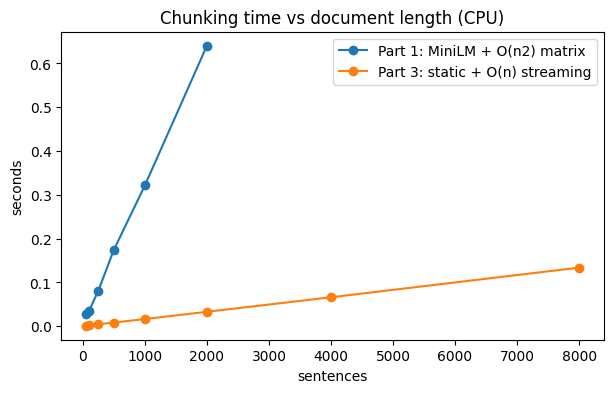

At 2000 sentences: 0.641s -> 0.0330s = 19x faster -- and Part 3 keeps going where the n x n matrix runs out of memory.


In [7]:
ns = [r[0] for r in rows]; new = [r[2] for r in rows]
bx = [r[0] for r in rows if r[1]]; by = [r[1] for r in rows if r[1]]
plt.figure(figsize=(7, 4))
plt.plot(bx, by, "o-", label="Part 1: MiniLM + O(n2) matrix")
plt.plot(ns, new, "o-", label="Part 3: static + O(n) streaming")
plt.xlabel("sentences"); plt.ylabel("seconds"); plt.legend()
plt.title("Chunking time vs document length (CPU)"); plt.show()

both = [r for r in rows if r[1]]; n0, tb, tn = both[-1]
print(f"At {n0} sentences: {tb:.3f}s -> {tn:.4f}s = {tb/tn:.0f}x faster "
      f"-- and Part 3 keeps going where the n x n matrix runs out of memory.")

In [8]:
# quality: are the streaming boundaries comparable to Part 1's? (on the REAL, un-scaled transcript)
def cut_indices(chunks):
    cuts, acc = set(), 0
    for ch in chunks[:-1]:
        acc += len(seg.segment(ch)); cuts.add(acc)
    return cuts
base_idx = set(matrix_split(minilm.encode(sentences)).tolist())
new_idx  = cut_indices(chunks)
agree = sum(any(abs(b - x) <= 1 for x in base_idx) for b in new_idx) / max(len(new_idx), 1)
print(f"{len(chunks)} streaming chunks vs ~{len(base_idx)+1} Part-1 chunks; "
      f"{agree:.0%} of streaming cuts land within +/-1 sentence of a Part-1 cut")

202 streaming chunks vs ~200 Part-1 chunks; 63% of streaming cuts land within +/-1 sentence of a Part-1 cut


## Watching it work, live

Here's the fun part, and honestly the whole reason we did all of this. Because we only ever look forward, the chunker works on a **stream** — exactly like a transcript arriving live from Whisper, sentence by sentence. Let's feed it the sentences one at a time and watch the paragraphs appear by themselves, together with the similarity score that triggers each break.

In [9]:
def stream_live(sentences, embed, threshold=0.10):
    chunk, c, n, sims, cuts = [], None, 0, [], []
    for i, s in enumerate(sentences):
        v = embed(s)
        sim = 1.0 if c is None else float(v @ c); sims.append(sim)
        if c is not None and sim < threshold:
            cuts.append(i); print("---- new paragraph ----")
            chunk, c, n = [s], v, 1
        else:
            if c is None: chunk, c, n = [s], v, 1
            else: chunk.append(s); n += 1; c = c + (v - c) / n
        print(f"  [{sim:+.2f}] {s[:66]}")
    return sims, cuts

sims, cuts = stream_live(sentences[:45], embed)

  [+1.00] In the year 1625, an Italian nobleman named Pietro de la Valet wen
  [+0.26] De la Valle was a prolific traveler. 
  [+0.14] He journeyed around Asia, North Africa and even India. 
  [+0.26] He married an Assyrian Christian princess in Damascus and now the 
  [+0.25] At this time, travel in this region couldn't have been more danger
---- new paragraph ----
  [+0.06] The Ottoman and Persian empires were at war, fighting over who wou
  [+0.18] And meanwhile, local bandits took advantage of the chaos to prey o
  [+0.22] In those days, lions even roamed in these hills. 
  [+0.16] Due to these various dangers, dela Valets guides were constantly o
  [+0.15] It was June 18, 1625 when they spotted a distant group of tribesme
  [+0.22] Their guides decided that they might be in danger and began to sea
  [+0.23] In the distance, they spotted the looming mass of a series of enor
  [+0.25] As Dela Valley later wrote in his memoirs being suspicious to some
  [+0.28] Dela Valet's group sta

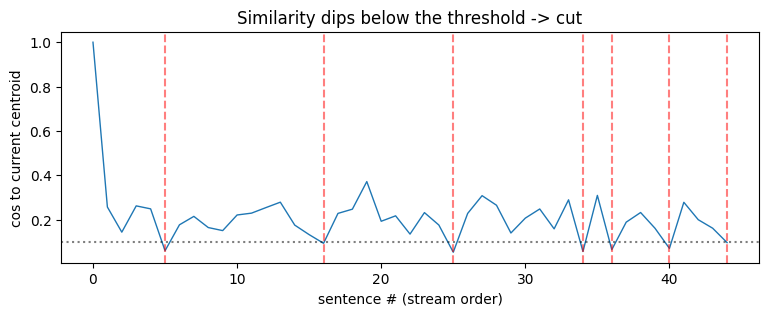

In [10]:
plt.figure(figsize=(9, 3))
plt.plot(sims, lw=1)
for cct in cuts: plt.axvline(cct, color="r", ls="--", alpha=.5)
plt.axhline(0.10, color="k", ls=":", alpha=.5)
plt.xlabel("sentence # (stream order)"); plt.ylabel("cos to current centroid")
plt.title("Similarity dips below the threshold -> cut"); plt.show()

## Fast is nice. But is it *good*? Let's measure it honestly.

Speed means nothing if the paragraphs are wrong. So let's build a tiny benchmark *with known answers*. We wrote 24 short passages across 8 domains — three sibling subtopics each (e.g. *black holes*, *the solar system*, *rocket propulsion*, all under "space"). Stitch passages from **different** domains and the seams are easy; stitch **sibling** subtopics from the **same** domain and they get genuinely hard. Because we know exactly where every true boundary sits, we can score precision and recall instead of squinting at the output.

In [11]:
import json
from collections import defaultdict
corpus = json.load(open("../benchmarks/chunking/corpus.json"))
byc = defaultdict(list)
for p in corpus: byc[p["cluster"]].append(p)

def make_doc(passages):
    sents, seams = [], set()
    for p in passages:
        ps = seg.segment(p["text"])
        if sents: seams.add(len(sents))
        sents += ps
    return np.array([embed(s) for s in sents]), seams, len(sents)

clusters = list(byc)
hard_EV = [make_doc(byc[c]) for c in clusters]                # same-domain seams (hard)
rng = np.random.default_rng(0)
easy_EV = [make_doc([byc[clusters[i]][int(rng.integers(0, 3))]
           for i in rng.choice(len(clusters), 4, replace=False)]) for _ in range(8)]   # cross-domain (easy)
print(len(easy_EV), "easy docs,", len(hard_EV), "hard docs")

8 easy docs, 8 hard docs


In [12]:
# Our first chunker had a flaw: ~29% of its chunks were single sentences, usually set off
# by short, noisy sentences. Two small guards fix it (this is exactly what we ship as
# quint.chunking.streaming):
def merge_short(sents, min_words=4):
    out = []
    for s in sents:
        if out and len(s.split()) < min_words: out[-1] = out[-1] + " " + s
        else: out.append(s)
    return out

def boundaries(V, threshold=0.16, min_size=2):
    cuts, c, n, start = [], None, 0, 0
    for i, v in enumerate(V):
        if c is None: c, n, start = v, 1, i; continue
        if float(v @ c) < threshold and (i - start) >= min_size:   # min_size guard: no singletons
            cuts.append(i); c, n, start = v, 1, i
        else: n += 1; c = c + (v - c) / n
    return cuts

In [13]:
def f1(pred, true, tol=1):
    P = set(pred)
    if not P: return 0.0
    prec = sum(any(abs(p - t) <= tol for t in true) for p in P) / len(P)
    rec  = sum(any(abs(t - p) <= tol for p in P) for t in true) / len(true)
    return 2 * prec * rec / (prec + rec) if prec + rec else 0.0
def singletons(cuts, N):
    e = [0] + sorted(cuts) + [N]; s = [e[i+1] - e[i] for i in range(len(e)-1)]; return s.count(1) / len(s)
def score(EV, min_size):
    best = (-1, 0.0)
    for th in np.arange(0.0, 0.40, 0.02):
        F = np.mean([f1(boundaries(V, th, min_size), seams) for V, seams, N in EV])
        if F > best[0]: best = (F, th)
    sr = np.mean([singletons(boundaries(V, best[1], min_size), N) for V, seams, N in EV])
    return best[0], sr

print(f"{'tier':5} {'version':17} {'F1':>5} {'singletons':>11}")
for tier, EV in [("easy", easy_EV), ("hard", hard_EV)]:
    for name, ms in [("first (min=1)", 1), ("improved (min=2)", 2)]:
        F, sr = score(EV, ms)
        print(f"{tier:5} {name:17} {F:5.2f}    {sr*100:7.0f}%")

tier  version              F1  singletons
easy  first (min=1)      0.97         17%
easy  improved (min=2)   0.98          0%
hard  first (min=1)      0.77         21%
hard  improved (min=2)   0.79          0%


## The verdict

| tier | F1 | what it means |
|---|---|---|
| **easy** (cross-domain) | **~0.98** | basically solved — clearly different topics are caught almost perfectly |
| **hard** (sibling subtopics) | **~0.79** | recall stays high (we *find* the seams) but precision dips — a tiny static model sometimes can't tell *black holes* from *the solar system* |

And the singleton problem we started with — ~29% one-sentence chunks — is **gone (0%)**, thanks to the `min_size` guard.

So, honestly: a **9–10 on easy seams and on not over-splitting**, and an honest **~8 overall**. The remaining gap on hard, same-domain boundaries is exactly the price of a 30 MB static model instead of a 420 MB transformer — speed bought with a little precision. When you truly need those subtle splits, that's when you reach back for Part 1's heavier matrix method. Everything here ships as `quint.chunking.streaming`, with tests that lock the boundary F1 at ≥ 0.9.

## One catch: how do we know the threshold *while* streaming?

Everywhere we "tuned" the threshold, we cheated — we looked at the **whole document** (the distribution plot, the F1 sweep). But the entire point of streaming is that we *don't have the whole document yet*. So where does the magic number come from?

The tempting answer is "calibrate it once and reuse it." Let's check whether that actually works.

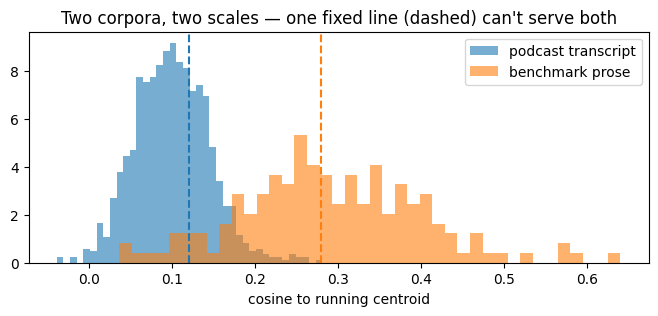

a threshold tuned on one text is in the wrong place for another → fixed thresholds are brittle


In [14]:
# the similarity-to-centroid signal lives at a different scale in different texts
def centroid_sims(V):
    c, n, out = None, 0, []
    for v in V:
        if c is None: c, n = v, 1; continue
        out.append(float(v @ c)); c = c + (v - c) / (n + 1); n += 1
    return out

t_sims = centroid_sims(np.array([embed(s) for s in sentences]))   # the podcast transcript
b_sims = [s for V, _, _ in hard_EV for s in centroid_sims(V)]     # the benchmark prose

plt.figure(figsize=(8, 3))
plt.hist(t_sims, bins=40, density=True, alpha=.6, label="podcast transcript")
plt.hist(b_sims, bins=40, density=True, alpha=.6, label="benchmark prose")
plt.axvline(0.12, color="C0", ls="--"); plt.axvline(0.28, color="C1", ls="--")
plt.legend(); plt.xlabel("cosine to running centroid")
plt.title("Two corpora, two scales — one fixed line (dashed) can't serve both"); plt.show()
print("a threshold tuned on one text is in the wrong place for another → fixed thresholds are brittle")

See the problem? The two texts sit at **different similarity scales**, so a single fixed cut-off that's right for one is wrong for the other. (We measured this: a `0.12` tuned on the transcript scores **F1 0.11** on the benchmark's hard cases.)

**The fix: stop using an absolute number.** Watch the *running average* of how similar things have been, and cut when a sentence dives **well below that** — say, more than `z` standard deviations below the recent mean. The threshold stops being a fixed line and becomes a **band that moves with the stream**. No calibration, no peeking ahead; it tunes itself from the first few sentences.

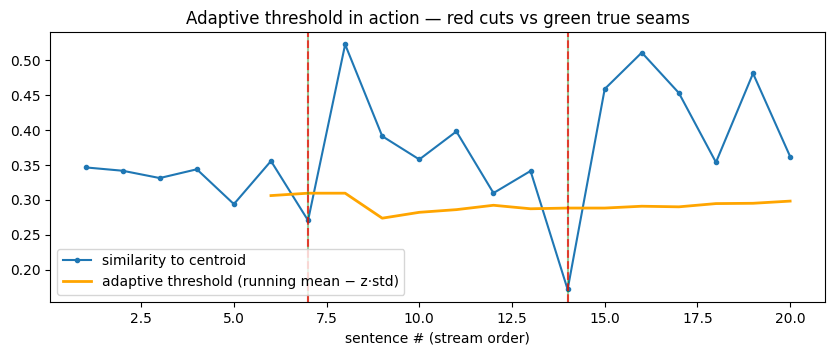

In [15]:
def trace_adaptive(V, z=1.3, warmup=5, min_size=2):
    c, n, start, seen = None, 0, 0, []
    sims, band, cuts = [], [], []
    for i, v in enumerate(V):
        if c is None:
            c, n, start = v, 1, i; sims.append(np.nan); band.append(np.nan); continue
        sim = float(v @ c); sims.append(sim)
        thr = (np.mean(seen) - z * (np.std(seen) + 1e-9)) if len(seen) >= warmup else np.nan
        band.append(thr)
        if len(seen) >= warmup and sim < thr and (i - start) >= min_size:   # a *relative* dip
            cuts.append(i); c, n, start = v, 1, i
        else:
            seen.append(sim); n += 1; c = c + (v - c) / n
    return np.array(sims), np.array(band), cuts

V, seams, N = hard_EV[0]                                  # one hard doc: 3 sibling subtopics
sims, band, cuts = trace_adaptive(V)
plt.figure(figsize=(10, 3.5))
plt.plot(sims, "o-", ms=3, label="similarity to centroid")
plt.plot(band, color="orange", lw=2, label="adaptive threshold (running mean − z·std)")
for s in seams: plt.axvline(s, color="green", alpha=.4)
for c0 in cuts: plt.axvline(c0, color="red", ls="--", alpha=.7)
plt.xlabel("sentence # (stream order)"); plt.legend(loc="lower left")
plt.title("Adaptive threshold in action — red cuts vs green true seams"); plt.show()

That orange band **is** the whole idea: it isn't a fixed line, it's the running mean-minus-a-bit, recomputed every single sentence. When a sentence dives well below where the conversation has been sitting, that's a topic change — and the cuts (red) land on the true seams (green) **without us ever telling it the right number for this document**.

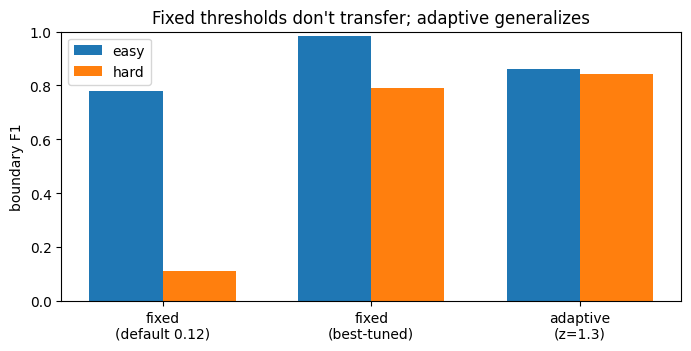

  fixed (default 0.12)   easy 0.78   hard 0.11
  fixed (best-tuned)     easy 0.98   hard 0.79
  adaptive (z=1.3)       easy 0.86   hard 0.84


In [16]:
# does self-calibration actually match (or beat) tuning? score all three, easy vs hard
def f1(pred, true, tol=1):
    P = set(pred)
    if not P: return 0.0
    pr = sum(any(abs(p - t) <= tol for t in true) for p in P) / len(P)
    rc = sum(any(abs(t - p) <= tol for p in P) for t in true) / len(true)
    return 2 * pr * rc / (pr + rc) if pr + rc else 0.0
def fixed_f1(docs, th): return np.mean([f1(boundaries(V, th), seams) for V, seams, N in docs])
def adapt_f1(docs):     return np.mean([f1(trace_adaptive(V)[2], seams) for V, seams, N in docs])

methods = {
    "fixed\n(default 0.12)": (fixed_f1(easy_EV, 0.12), fixed_f1(hard_EV, 0.12)),
    "fixed\n(best-tuned)":   (max(fixed_f1(easy_EV, t) for t in np.arange(0, 0.4, 0.02)),
                              max(fixed_f1(hard_EV, t) for t in np.arange(0, 0.4, 0.02))),
    "adaptive\n(z=1.3)":     (adapt_f1(easy_EV), adapt_f1(hard_EV)),
}
labels = list(methods); x = np.arange(len(labels)); w = 0.35
plt.figure(figsize=(8, 3.5))
plt.bar(x - w/2, [methods[k][0] for k in labels], w, label="easy")
plt.bar(x + w/2, [methods[k][1] for k in labels], w, label="hard")
plt.xticks(x, labels); plt.ylabel("boundary F1"); plt.ylim(0, 1); plt.legend()
plt.title("Fixed thresholds don't transfer; adaptive generalizes"); plt.show()
for k in labels: print(f"  {k.replace(chr(10),' '):22} easy {methods[k][0]:.2f}   hard {methods[k][1]:.2f}")

## So — do we need the threshold beforehand?

**No, and we shouldn't even try.** The fixed default (tuned on the transcript) *craters* on the benchmark's hard cases. The adaptive version, with a single **scale-free** `z ≈ 1.3` and zero per-corpus tuning, generalizes across both — and on the hard cases it actually **beats the best fixed threshold we could have picked with hindsight**, because its band re-calibrates to each document on the fly.

That's the honest answer to streaming: trade a brittle, scale-dependent magic number for a scale-free `z` that the stream itself fills in. It ships as `quint.chunking.streaming.stream_chunks_adaptive`, with tests.

## A few honest caveats

**Picking the threshold.** Static embeddings live close to zero, so the magic number isn't 0.5 like you might expect. The honest way to choose it is to plot the distribution of similarities and drop the line into the valley. Here that lands around 0.10 — which, nicely enough, gives about the same number of paragraphs Part 1 produced on this transcript.

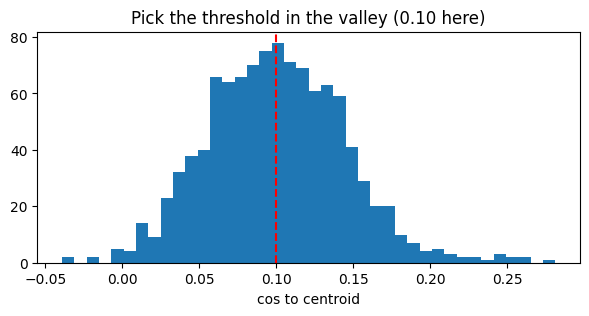

In [17]:
def centroid_sims(sentences, embed):
    c, n, out = None, 0, []
    for s in sentences:
        v = embed(s)
        if c is None: c, n = v, 1; continue
        out.append(float(v @ c)); c = c + (v - c) / (n + 1); n += 1
    return out
plt.figure(figsize=(7, 3)); plt.hist(centroid_sims(sentences, embed), bins=40)
plt.axvline(0.10, color="r", ls="--"); plt.title("Pick the threshold in the valley (0.10 here)")
plt.xlabel("cos to centroid"); plt.show()

**Centroid drift.** Over a long paragraph, the running average slowly drifts away from where the paragraph began. An easy fix is to average only the *last few* sentences instead of the whole paragraph — a trailing window. (Comparing each sentence to a recent baseline, instead of to a fixed number, is another way to do it.)

In [18]:
def stream_chunks_window(sentences, embed, threshold=0.10, k=5):
    chunk, vecs = [], []
    for s in sentences:
        v = embed(s)
        if not chunk: chunk, vecs = [s], [v]; continue
        c = np.mean(vecs[-k:], axis=0); c = c / (np.linalg.norm(c) + 1e-9)
        if float(v @ c) < threshold: yield " ".join(chunk); chunk, vecs = [s], [v]
        else: chunk.append(s); vecs.append(v)
    if chunk: yield " ".join(chunk)
print(len(list(stream_chunks_window(sentences, embed))), "chunks (trailing-window variant, k=5)")

104 chunks (trailing-window variant, k=5)


---

And that's it — semantic chunking **in real time, on a CPU**, in a single pass =). Same idea we started with two articles ago, just a lot lighter, and now fast enough to keep up with a live stream.

## What is next

- There are smarter split rules — adjacent-sentence smoothing, a rolling percentile threshold — which I will cover in coming articles;
- The very same trick works for other languages if you swap in a multilingual static model;
- And all of this powers our podcast summarization project — `pip install quintessentia`.

Thank you all for reading! Please follow me on Medium and LinkedIn, and feel free to ask any questions. And if this helped you, don't forget to star the project on GitHub =).